In [ ]:
# ===========================================
# 1. Setup & Imports
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

# ===========================================
# 2. Load Data
# ===========================================
df = pd.read_csv('data/benin.csv', parse_dates=['Timestamp'])

print("✅ Data loaded successfully!")
print(df.info())
display(df.head())

# ===========================================
# 3. Summary Statistics & Missing Values
# ===========================================
display(df.describe())
missing_report = df.isna().sum().reset_index()
missing_report.columns = ['Column', 'Missing_Count']
missing_report['Missing_%'] = 100 * missing_report['Missing_Count'] / len(df)
display(missing_report[missing_report['Missing_%'] > 5])

# ===========================================
# 4. Outlier Detection (Z-score)
# ===========================================
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
for col in cols:
    df[f'z_{col}'] = stats.zscore(df[col].fillna(df[col].median()))

outlier_flags = (df[[f'z_{col}' for col in cols]].abs() > 3).any(axis=1)
print(f"Outlier rows detected: {outlier_flags.sum()}")

# ===========================================
# 5. Cleaning (Median Imputation)
# ===========================================
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

# Drop outliers if needed
df_clean = df[~outlier_flags].copy()

# ===========================================
# 6. Export Cleaned Data (locally only)
# ===========================================
df_clean.to_csv('data/benin_clean.csv', index=False)
print("💾 Cleaned data saved locally to data/benin_clean.csv")

# ===========================================
# 7. Time Series Analysis
# ===========================================
fig, ax = plt.subplots(figsize=(12,6))
df_clean.plot(x='Timestamp', y=['GHI','DNI','DHI'], ax=ax)
plt.title('Solar Irradiance vs Time')
plt.show()

# ===========================================
# 8. Correlation & Scatter Plots
# ===========================================
sns.heatmap(df_clean[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.scatterplot(x='WS', y='GHI', data=df_clean)
plt.title("Wind Speed vs GHI")
plt.show()

# ===========================================
# 9. Bubble Chart (GHI vs Tamb with RH size)
# ===========================================
if {'Tamb','RH','BP'}.issubset(df_clean.columns):
    fig = px.scatter(df_clean, x='Tamb', y='GHI', size='RH', color='BP',
                     title='GHI vs Tamb (bubble size = RH)')
    fig.show()


FileNotFoundError: [Errno 2] No such file or directory: 'data/benin.csv'

Loading data from /content/benin-malanville.csv
===== SUMMARY STATISTICS (numeric columns) =====


,count,mean,std,min,25%,50%,75%,max
GHI,525600.0,240.559452,331.131327,-12.9,-2.0,1.8,483.4,1413.0
DNI,525600.0,167.187516,261.710501,-7.8,-0.5,-0.1,314.2,952.3
DHI,525600.0,115.358961,158.691074,-12.6,-2.1,1.6,216.3,759.2
ModA,525600.0,236.589496,326.894859,0.0,0.0,4.5,463.7,1342.3
ModB,525600.0,228.883576,316.536515,0.0,0.0,4.3,447.9,1342.3
Tamb,525600.0,28.179683,5.924297,11.0,24.2,28.0,32.3,43.8
RH,525600.0,54.487969,28.073069,2.1,28.8,55.1,80.1,100.0
WS,525600.0,2.121113,1.603466,0.0,1.0,1.9,3.1,19.5
WSgust,525600.0,2.809195,2.029120,0.0,1.3,2.6,4.1,26.6
WSstdev,525600.0,0.473390,0.273395,0.0,0.4,0.5,0.6,4.2



===== MISSING VALUES =====


,missing_count,missing_pct
Timestamp,0,0.0
GHI,0,0.0
DNI,0,0.0
DHI,0,0.0
ModA,0,0.0
ModB,0,0.0
Tamb,0,0.0
RH,0,0.0
WS,0,0.0
WSgust,0,0.0


Columns with >5% nulls: ['Comments']
Flagged 8551 rows with |Z| > 3.0 in ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust', 'Tamb', 'RH', 'BP', 'WD'].
Total outliers flagged: 8551
Cleaned data saved to data/<benin>_clean.csv (ensure data/ is in .gitignore and not committed)


<Figure size 1400x600 with 0 Axes>

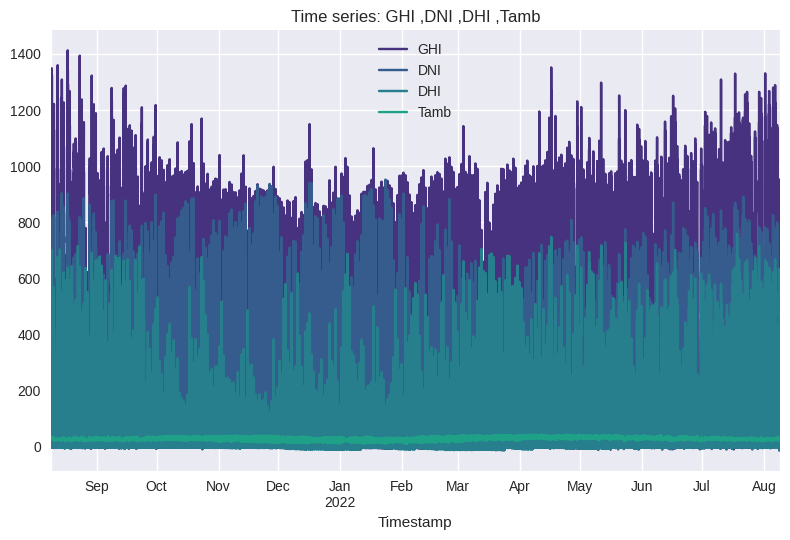

/tmp/ipython-input-59489592.py:107: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df[cols].resample('M').mean()


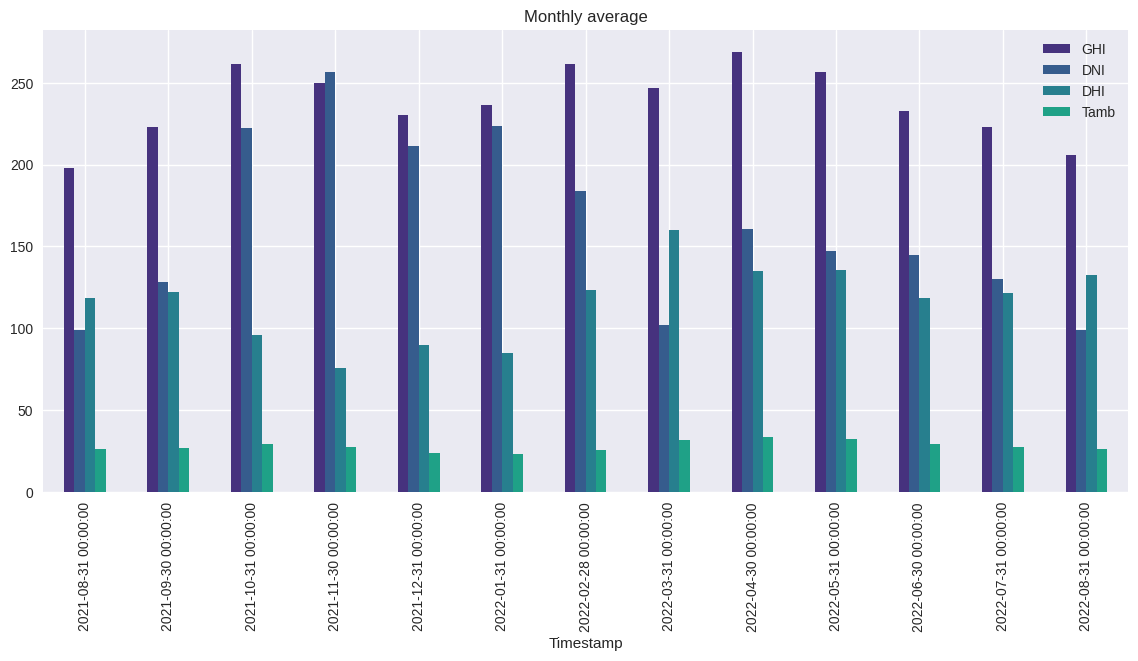

,ModA,ModB
cleaned_flag,,
False,236.589496,228.883576


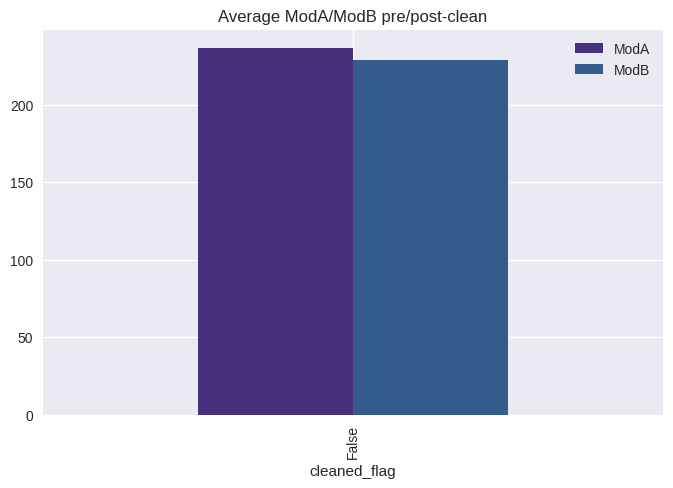

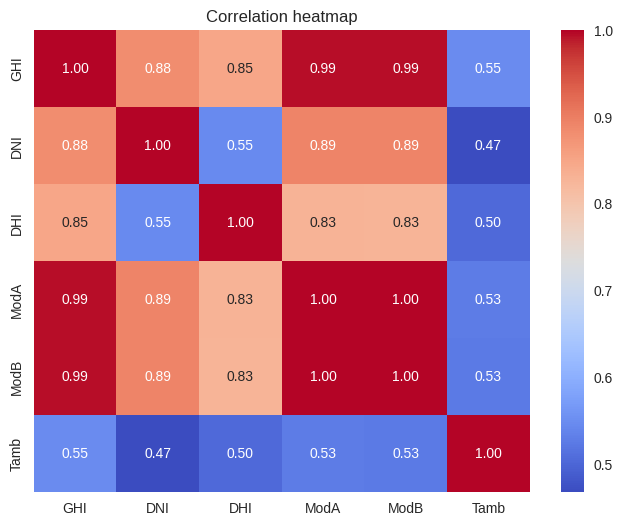

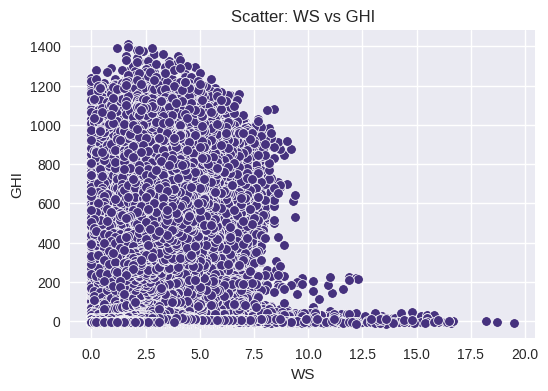

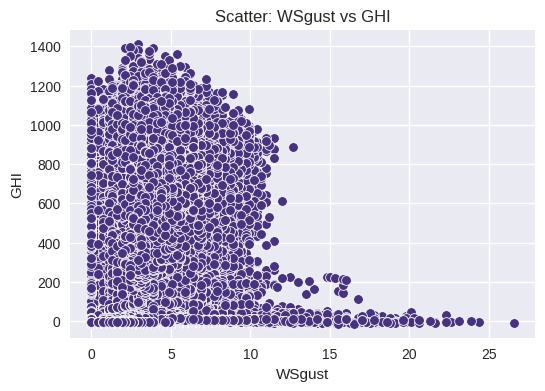

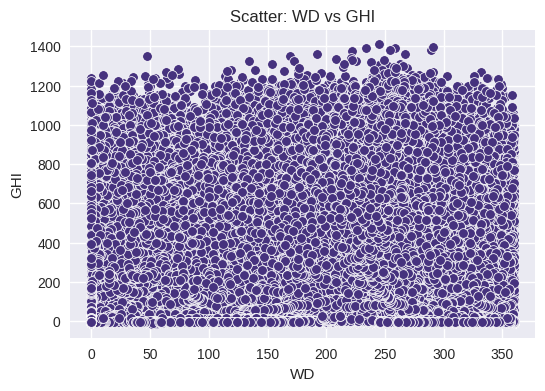

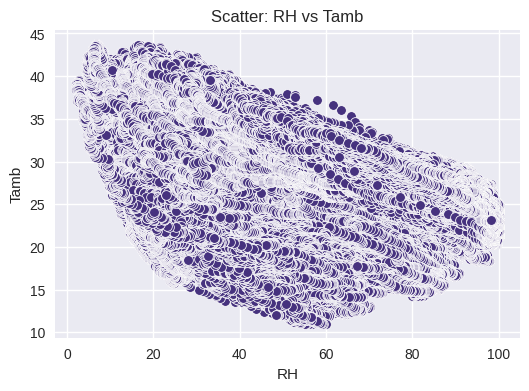

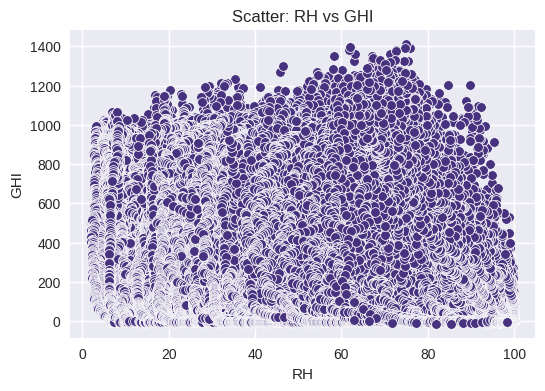

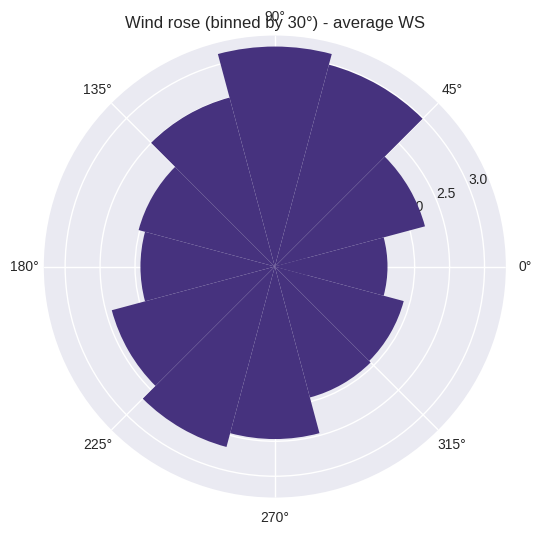

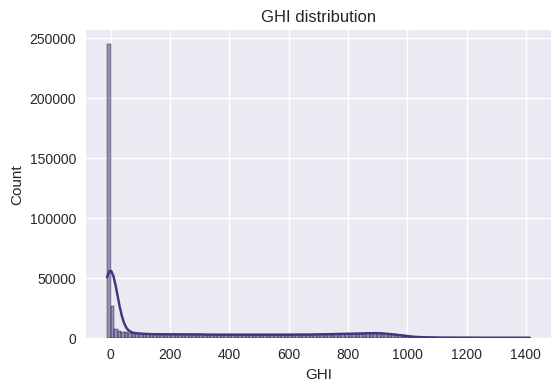

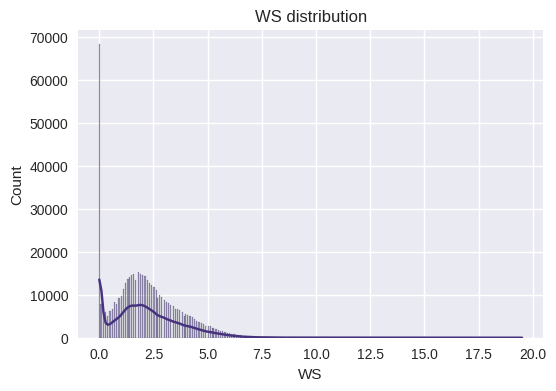

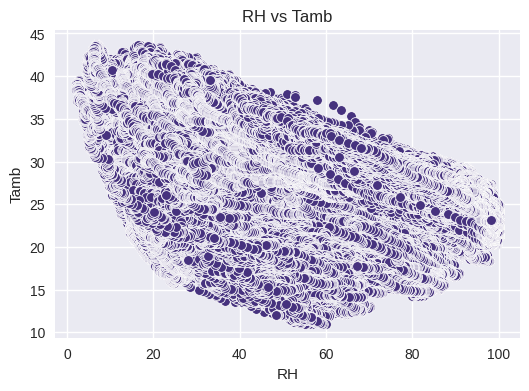

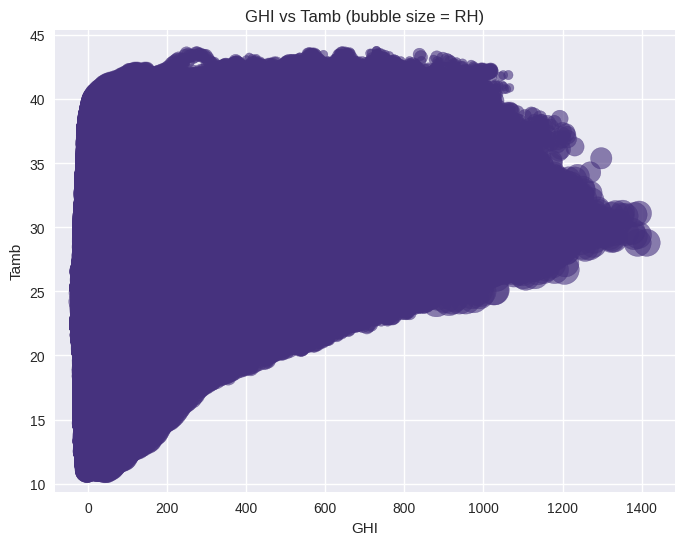


=== SUGGESTED KPIs & NEXT STEPS ===
- Percentage of missing values per critical sensor (GHI/DNI/DHI).
- Number/percent of outliers detected in sensor columns (Z>|3|).
- Pre/post-cleaning mean and variance for ModA/ModB to check for bias introduced by imputation.
- Seasonal patterns: compute monthly and diurnal averages for GHI and Tamb.


In [4]:
# country_eda_template.py
# Template EDA pipeline for solar datasets. Replace <COUNTRY> and file paths as needed.
# Save as <country>_eda.ipynb or run in a Jupyter notebook cell-by-cell.

import os
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Configuration - update these
# -----------------------------
COUNTRY = "<benin>"  # replace with country name, e.g. 'benin'
RAW_PATH = f"/content/benin-malanville.csv"  # path to raw data
CLEAN_PATH = f"data/{COUNTRY}_clean.csv"  # path to write cleaned CSV (data/ must be in .gitignore)
TIMESTAMP_COL = "Timestamp"  # change if different

# Key columns expected (adjust to your dataset's actual column names)
NUMERIC_COLS = ["GHI", "DNI", "DHI", "ModA", "ModB", "WS", "WSgust", "Tamb", "RH", "BP", "WD"]
CLEANING_FLAG_COL = "cleaned_flag"  # used to mark rows changed by cleaning (created below)

# -----------------------------
# Utility functions
# -----------------------------

def ensure_data_dir():
    Path("data").mkdir(exist_ok=True)
    # Add reminder to .gitignore
    gitignore = Path('.gitignore')
    if gitignore.exists():
        txt = gitignore.read_text()
        if 'data/' not in txt:
            gitignore.write_text(txt + '\n# local data\ndata/\n')
    else:
        gitignore.write_text('# local data\ndata/\n')


def load_data(path=RAW_PATH):
    df = pd.read_csv(path, parse_dates=[TIMESTAMP_COL])
    df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
    return df


def summary_and_missing(df):
    print("===== SUMMARY STATISTICS (numeric columns) =====")
    display(df.describe(include=[np.number]).T)

    print("\n===== MISSING VALUES =====")
    miss = df.isna().sum()
    miss_pct = (miss / len(df)) * 100
    report = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    display(report)

    cols_over_5pct = report[report['missing_pct'] > 5].index.tolist()
    if cols_over_5pct:
        print(f"Columns with >5% nulls: {cols_over_5pct}")
    else:
        print("No column has more than 5% nulls.")

    return report


def detect_outliers_zscore(df, cols=NUMERIC_COLS, threshold=3.0):
    # compute z-score for specified columns, robust to NaNs
    z = df[cols].apply(lambda x: stats.zscore(x, nan_policy='omit'))
    # z will have NaNs where original NaNs
    outlier_mask = (z.abs() > threshold)
    outlier_rows = outlier_mask.any(axis=1)
    print(f"Flagged {outlier_rows.sum()} rows with |Z| > {threshold} in {cols}.")
    return outlier_mask, outlier_rows


def impute_or_drop(df, key_cols=NUMERIC_COLS):
    df = df.copy()
    df[CLEANING_FLAG_COL] = False
    for col in key_cols:
        if col in df.columns:
            n_missing_before = df[col].isna().sum()
            if n_missing_before > 0:
                med = df[col].median()
                df[col].fillna(med, inplace=True)
                df.loc[df[col].isna() == False, CLEANING_FLAG_COL] = True
    return df

# -----------------------------
# Plotting helpers
# -----------------------------

def time_series_plots(df, ts_col=TIMESTAMP_COL):
    df = df.set_index(ts_col)
    cols = [c for c in ["GHI", "DNI", "DHI", "Tamb"] if c in df.columns]
    if not cols:
        print('No time series columns found among expected list.')
        return

    plt.figure(figsize=(14, 6))
    df[cols].plot(subplots=False)
    plt.title(f"Time series: {' ,'.join(cols)}")
    plt.xlabel('Timestamp')
    plt.tight_layout()
    plt.show()

    # monthly aggregation
    monthly = df[cols].resample('M').mean()
    monthly.plot(kind='bar', figsize=(14,6))
    plt.title('Monthly average')
    plt.show()


def cleaning_impact(df):
    if CLEANING_FLAG_COL not in df.columns:
        print('Cleaning flag column not present.')
        return
    cols = [c for c in ["ModA", "ModB"] if c in df.columns]
    if not cols:
        print('No module sensor columns found to compare.')
        return
    grouped = df.groupby(CLEANING_FLAG_COL)[cols].mean()
    display(grouped)
    grouped.plot(kind='bar', figsize=(8,5))
    plt.title('Average ModA/ModB pre/post-clean')
    plt.show()


def correlation_and_scatter(df):
    cols = [c for c in ["GHI", "DNI", "DHI", "ModA", "ModB", "Tamb"] if c in df.columns]
    if len(cols) >= 2:
        plt.figure(figsize=(8,6))
        sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
        plt.title('Correlation heatmap')
        plt.show()

    # scatter examples
    pairs = [(["WS","GHI"],["WSgust","GHI"],["WD","GHI"])]
    for p in [("WS","GHI"),("WSgust","GHI"),("WD","GHI"),("RH","Tamb"),("RH","GHI")]:
        x,y = p
        if x in df.columns and y in df.columns:
            plt.figure(figsize=(6,4))
            sns.scatterplot(data=df, x=x, y=y)
            plt.title(f"Scatter: {x} vs {y}")
            plt.show()


def wind_analysis(df):
    # Wind rose approximation: aggregate by direction bin and average speed
    if not set(["WS","WD"]).issubset(df.columns):
        print('WS and WD required for wind analysis.')
        return
    tmp = df.dropna(subset=['WS','WD']).copy()
    tmp['wd_bin'] = (tmp['WD'] // 30) * 30
    pivot = tmp.groupby('wd_bin')['WS'].mean().reset_index()
    # polar bar plot
    theta = np.deg2rad(pivot['wd_bin'])
    radii = pivot['WS']
    width = np.deg2rad(30)
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, polar=True)
    ax.bar(theta, radii, width=width)
    ax.set_title('Wind rose (binned by 30°) - average WS')
    plt.show()


def distributions(df):
    # histograms
    if 'GHI' in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df['GHI'].dropna(), kde=True)
        plt.title('GHI distribution')
        plt.show()
    if 'WS' in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df['WS'].dropna(), kde=True)
        plt.title('WS distribution')
        plt.show()


def temperature_and_rh(df):
    if set(['Tamb','RH']).issubset(df.columns):
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=df, x='RH', y='Tamb')
        plt.title('RH vs Tamb')
        plt.show()


def bubble_chart(df):
    if set(['GHI','Tamb','RH']).issubset(df.columns):
        plt.figure(figsize=(8,6))
        sizes = (df['RH'].fillna(df['RH'].median()) + 1) * 5
        plt.scatter(df['GHI'], df['Tamb'], s=sizes, alpha=0.6)
        plt.xlabel('GHI')
        plt.ylabel('Tamb')
        plt.title('GHI vs Tamb (bubble size = RH)')
        plt.show()

# -----------------------------
# Main pipeline
# -----------------------------

def run_pipeline(raw_path=RAW_PATH, clean_path=CLEAN_PATH):
    ensure_data_dir()

    print(f"Loading data from {raw_path}")
    df = load_data(raw_path)

    # Quick profile
    missing_report = summary_and_missing(df)

    # Outlier detection
    numeric_present = [c for c in NUMERIC_COLS if c in df.columns]
    outlier_mask, outlier_rows = detect_outliers_zscore(df, cols=numeric_present)

    # Tag outliers in the dataframe
    for c in numeric_present:
        df[f'{c}_zscore'] = stats.zscore(df[c].fillna(df[c].median()))
    df['is_outlier'] = df[[f'{c}_zscore' for c in numeric_present]].abs().gt(3).any(axis=1)

    print(f"Total outliers flagged: {df['is_outlier'].sum()}")

    # Basic cleaning: impute medians for key numeric cols
    df_clean = impute_or_drop(df, key_cols=numeric_present)

    # Save cleaned df
    df_clean.to_csv(clean_path, index=False)
    print(f"Cleaned data saved to {clean_path} (ensure data/ is in .gitignore and not committed)")

    # EDA plots
    time_series_plots(df_clean)
    cleaning_impact(df_clean)
    correlation_and_scatter(df_clean)
    wind_analysis(df_clean)
    distributions(df_clean)
    temperature_and_rh(df_clean)
    bubble_chart(df_clean)

    # Report KPIs / suggestions
    print('\n=== SUGGESTED KPIs & NEXT STEPS ===')
    print('- Percentage of missing values per critical sensor (GHI/DNI/DHI).')
    print('- Number/percent of outliers detected in sensor columns (Z>|3|).')
    print('- Pre/post-cleaning mean and variance for ModA/ModB to check for bias introduced by imputation.')
    print('- Seasonal patterns: compute monthly and diurnal averages for GHI and Tamb.')

    return df_clean


# If this file is run as a script, execute the pipeline (useful for quick tests)
if __name__ == '__main__':
    # User can change RAW_PATH and COUNTRY above, or pass via CLI/env
    if not Path(RAW_PATH).exists():
        print(f"Raw file not found: {RAW_PATH}. Please update RAW_PATH or place the file there.")
    else:
        run_pipeline()

# References (for learning - search these titles online):
# - "Exploratory Data Analysis" by John Tukey
# - "Practical Statistics for Data Scientists" (2nd ed.)
# - "Applied Time Series Analysis with Python" tutorials
# - seaborn/matplotlib/pandas documentation
